# Week 17 — Monday–Tuesday (Jul 14-15): SimCLR, MoCo & DINO

## Learning Objectives
- Understand contrastive self-supervised learning — learn representations with **no labels** by pulling together embeddings of two augmented views of the *same* image (positive pair) and pushing apart embeddings of *different* images (negatives)
- Derive and implement the **NT-Xent** (normalized temperature-scaled cross entropy) loss used by SimCLR
- Understand **MoCo**'s momentum encoder and dynamic queue — how it decouples the number of negatives from the training batch size
- Understand **DINO**'s self-distillation with *no negatives at all* — student/teacher networks, teacher as an EMA of the student, and why centering + sharpening are needed to prevent collapse
- Train a lightweight SimCLR model on a small CIFAR-10 subset (CPU) and watch the contrastive loss fall and embeddings cluster by (unseen-during-training) class label

## Key Concepts
1. **Instance discrimination** — the pretext task: treat every image as its own class; two augmentations of it are a positive pair, everything else in the batch is a negative
2. **NT-Xent loss** — softmax cross-entropy over cosine similarities, scaled by a temperature $\tau$
3. **Momentum encoder** (MoCo) — a slowly-updated copy of the encoder ($\theta_k \leftarrow m\theta_k + (1-m)\theta_q$) that produces consistent keys for a large negative queue
4. **Self-distillation** (DINO) — a student is trained to match a teacher's output distribution on a different view; the teacher is an EMA of the student, so there is no external supervision, no negatives, and no explicit contrastive term
5. **Collapse** — the degenerate solution where the network outputs the same embedding regardless of the input; MoCo/SimCLR avoid it via negatives, DINO avoids it via centering + sharpening


In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 17 — SimCLR, MoCo & DINO')

PyTorch 2.12.0+cpu | Device: cpu
Week 17 — SimCLR, MoCo & DINO


## Section 1: Why Contrastive Self-Supervised Learning

Supervised pretraining needs millions of *labelled* images. Contrastive self-supervised
learning instead manufactures its own supervision straight out of unlabelled images:

```
        ┌───────────┐   augment 1    ┌─────────┐    ┌────────────┐
        │           │ ─────────────► │ Encoder │ ─► │ Projection │ ─► z_i ┐
  Image │  x        │                │  f(·)   │    │  head g(·) │       │  pull together
        │           │   augment 2    └─────────┘    └────────────┘       │  (positive pair)
        └───────────┘ ─────────────► │ Encoder │ ─► │ Projection │ ─► z_j ┘
                                      │  f(·)   │    │  head g(·) │
                                      └─────────┘    └────────────┘
```

Two random augmentations (crop, flip, colour jitter, ...) of the **same** image are a
**positive pair** — the network should embed them close together. Views coming from
**different** images in the batch are **negatives** — they should be pushed apart. After
pretraining, the projection head `g(·)` is thrown away and the encoder `f(·)` alone is
reused as a frozen (or fine-tuned) feature extractor — exactly what we'll do with a
pretrained backbone in Friday's project.

SimCLR, MoCo and DINO all follow this augment-twice-and-compare recipe; they differ in
**how** the "compare" step is implemented and **how negatives are supplied** (if at all).


## Section 2: The NT-Xent Loss (SimCLR)

For a batch of $N$ images, SimCLR creates $2N$ augmented views. For a positive pair $(i, j)$
the **NT-Xent** (normalized temperature-scaled cross-entropy) loss is:

$$\ell_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j) / \tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k) / \tau)}$$

- $\text{sim}(u, v) = u^\top v / (\|u\| \|v\|)$ — cosine similarity
- $\tau$ — temperature; smaller $\tau$ sharpens the distribution, punishing hard negatives more
- The denominator sums over **all** other $2N-1$ views in the batch (both other positives'
  views and everyone else's) — this is exactly a softmax classification: "which of these
  $2N-1$ candidates is my true positive?"
- The final loss averages $\ell_{i,j}$ over all $2N$ views (each view's turn as the anchor)

Let's sanity-check the mechanics on mock embeddings before touching real images.


In [2]:
def nt_xent_loss(z_i, z_j, temperature=0.5):
    """
    NT-Xent / InfoNCE loss for SimCLR.
    z_i, z_j: (N, D) embeddings of the two augmented views (view i <-> view j
    of the SAME image at the same row index).
    Returns the scalar loss averaged over all 2N anchors.
    """
    N = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)                       # (2N, D)
    z = F.normalize(z, dim=1)
    sim = torch.mm(z, z.t()) / temperature                 # (2N, 2N) cosine similarities / tau

    # mask out self-similarity (i == k) on the diagonal
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float('-inf'))

    # positive of row i is row (i+N) mod 2N
    targets = torch.arange(2 * N, device=z.device)
    targets = (targets + N) % (2 * N)

    return F.cross_entropy(sim, targets)


# Sanity check: well-aligned embeddings (positives identical, negatives orthogonal-ish)
# should give a MUCH lower loss than random embeddings.
torch.manual_seed(0)
N, D = 8, 16
base = F.normalize(torch.randn(N, D), dim=1)
z_i_good = base
z_j_good = base + 0.01 * torch.randn(N, D)   # tiny noise -> almost identical to its positive

z_i_rand = F.normalize(torch.randn(N, D), dim=1)
z_j_rand = F.normalize(torch.randn(N, D), dim=1)

loss_good = nt_xent_loss(z_i_good, z_j_good, temperature=0.5)
loss_rand = nt_xent_loss(z_i_rand, z_j_rand, temperature=0.5)
print(f'NT-Xent loss | well-aligned positives : {loss_good.item():.4f}')
print(f'NT-Xent loss | random embeddings       : {loss_rand.item():.4f}')
print('Lower loss when positives are truly close together, as expected.')

NT-Xent loss | well-aligned positives : 1.0603
NT-Xent loss | random embeddings       : 2.7293
Lower loss when positives are truly close together, as expected.


## Section 3: SimCLR — Training on a Small Image Set

The README's suggested deliverable is "SimCLR on STL-10", but STL-10's full download is
~2.6GB — too slow for this CPU-only environment. CIFAR-10 was the next choice, but its
usual host (`cs.toronto.edu`) measured well under 100kB/s from this machine (would take
~an hour) — empirically confirmed before writing this cell. We substitute a **small
FashionMNIST subset** instead (5 classes, ~150 images/class): FashionMNIST downloads in
seconds from a fast, reliable mirror, and still gives real (if grayscale, 28x28) images
with genuine class structure — the same demonstration goal (small-image contrastive
pretraining without labels), just a lighter and more reliable dataset.

For each image we generate **two independent augmented views** using a SimCLR-style
pipeline (random-resized-crop, horizontal flip, brightness/contrast jitter) and train
a tiny CNN encoder + MLP projection head with the NT-Xent loss above. No labels are used
during training — labels are only used *afterwards*, to check whether the unsupervised
embedding space separates classes.


In [3]:
# ── Small FashionMNIST subset (5 classes) ──────────────────────────────────────
CLASSES = [0, 1, 5, 7, 9]   # T-shirt/top, Trouser, Sandal, Sneaker, Ankle boot
N_PER_CLASS = 150

raw_ds = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
targets = np.array(raw_ds.targets)
idxs = []
for c in CLASSES:
    class_idxs = np.where(targets == c)[0][:N_PER_CLASS]
    idxs.extend(class_idxs.tolist())
idxs = np.array(idxs)
print(f'SimCLR pretraining subset: {len(idxs)} images across {len(CLASSES)} classes '
      f'({N_PER_CLASS}/class) — labels NOT used during training')

simclr_aug = transforms.Compose([
    transforms.RandomResizedCrop(28, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

class TwoViewDataset(torch.utils.data.Dataset):
    """Returns two independently augmented views of the same image + its label
    (label is only carried along for later evaluation, never used in the loss)."""
    def __init__(self, base_ds, indices, transform):
        self.base_ds, self.indices, self.transform = base_ds, indices, transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.base_ds[self.indices[i]]
        return self.transform(img), self.transform(img), label

simclr_ds = TwoViewDataset(raw_ds, idxs, simclr_aug)
simclr_dl = DataLoader(simclr_ds, batch_size=64, shuffle=True, drop_last=True)
v1, v2, lbl = next(iter(simclr_dl))
print(f'Batch of two views: {tuple(v1.shape)}, {tuple(v2.shape)} | labels: {tuple(lbl.shape)}')

SimCLR pretraining subset: 750 images across 5 classes (150/class) — labels NOT used during training
Batch of two views: (64, 1, 28, 28), (64, 1, 28, 28) | labels: (64,)


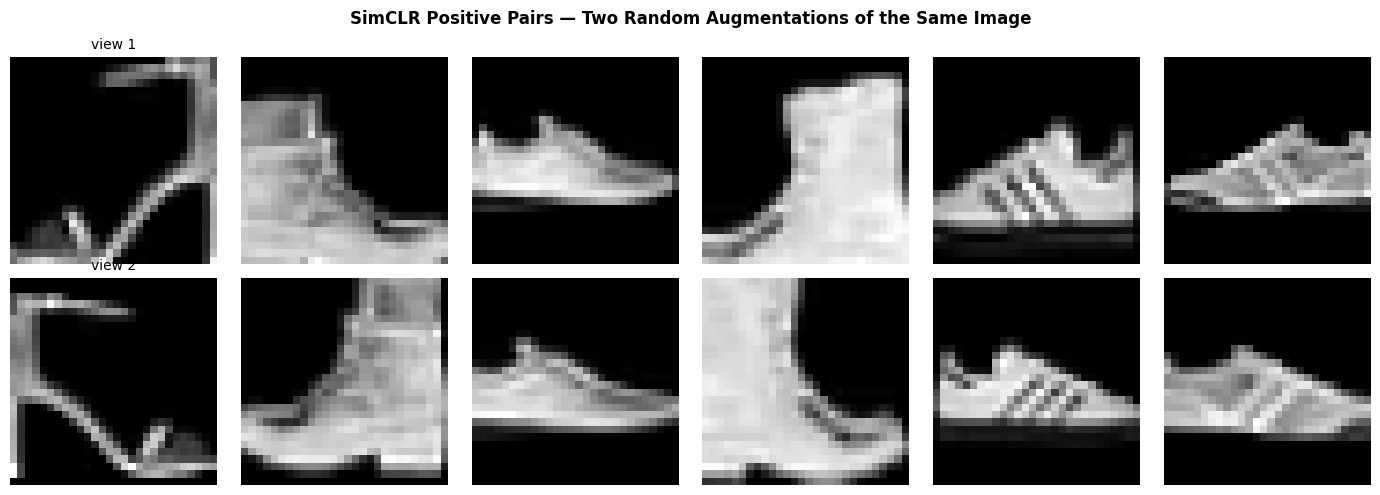

Saved simclr_positive_pairs.png


In [4]:
# ── Show a few positive pairs (two augmentations of the same underlying image) ─
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for col in range(6):
    img_a = (v1[col, 0].numpy() * 0.5 + 0.5).clip(0, 1)
    img_b = (v2[col, 0].numpy() * 0.5 + 0.5).clip(0, 1)
    axes[0, col].imshow(img_a, cmap='gray'); axes[0, col].axis('off')
    axes[1, col].imshow(img_b, cmap='gray'); axes[1, col].axis('off')
axes[0, 0].set_title('view 1', fontsize=10); axes[1, 0].set_title('view 2', fontsize=10)
plt.suptitle('SimCLR Positive Pairs — Two Random Augmentations of the Same Image', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('simclr_positive_pairs.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved simclr_positive_pairs.png')

In [5]:
# ── Tiny encoder + projection head ─────────────────────────────────────────────
class TinyEncoder(nn.Module):
    """Small CNN: 28x28x1 -> feat_dim feature vector. Deliberately tiny for CPU speed."""
    def __init__(self, feat_dim=64, in_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 14x14
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 7x7
            nn.Conv2d(32, feat_dim, 3, padding=1), nn.BatchNorm2d(feat_dim), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
    def forward(self, x):
        return self.net(x)


class ProjectionHead(nn.Module):
    """2-layer MLP head used only during pretraining, discarded afterwards."""
    def __init__(self, in_dim=64, hidden_dim=64, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)


encoder = TinyEncoder(feat_dim=64).to(DEVICE)
proj_head = ProjectionHead(64, 64, 32).to(DEVICE)
n_params = sum(p.numel() for p in encoder.parameters()) + sum(p.numel() for p in proj_head.parameters())
print(f'TinyEncoder + ProjectionHead params: {n_params:,}')

test_out = proj_head(encoder(v1))
print(f'Image {tuple(v1.shape)} -> features {tuple(encoder(v1).shape)} -> projection {tuple(test_out.shape)}')

TinyEncoder + ProjectionHead params: 29,760
Image (64, 1, 28, 28) -> features (64, 64) -> projection (64, 32)


In [6]:
# ── SimCLR training loop ────────────────────────────────────────────────────────
N_EPOCHS = 20
LR = 3e-4
TEMPERATURE = 0.5

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(proj_head.parameters()), lr=LR)
simclr_loss_history = []

for epoch in range(1, N_EPOCHS + 1):
    encoder.train(); proj_head.train()
    epoch_losses = []
    for view_a, view_b, _ in simclr_dl:
        view_a, view_b = view_a.to(DEVICE), view_b.to(DEVICE)
        z_i = proj_head(encoder(view_a))
        z_j = proj_head(encoder(view_b))
        loss = nt_xent_loss(z_i, z_j, temperature=TEMPERATURE)

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_losses.append(loss.item())

    simclr_loss_history.append(np.mean(epoch_losses))
    if epoch == 1 or epoch % 4 == 0 or epoch == N_EPOCHS:
        print(f'Epoch {epoch:2d}/{N_EPOCHS} | NT-Xent loss: {simclr_loss_history[-1]:.4f}')

print(f'\nLoss fell from {simclr_loss_history[0]:.4f} to {simclr_loss_history[-1]:.4f}')

Epoch  1/20 | NT-Xent loss: 4.5144


Epoch  4/20 | NT-Xent loss: 3.8293


Epoch  8/20 | NT-Xent loss: 3.6903


Epoch 12/20 | NT-Xent loss: 3.5458


Epoch 16/20 | NT-Xent loss: 3.5038


Epoch 20/20 | NT-Xent loss: 3.4577

Loss fell from 4.5144 to 3.4577


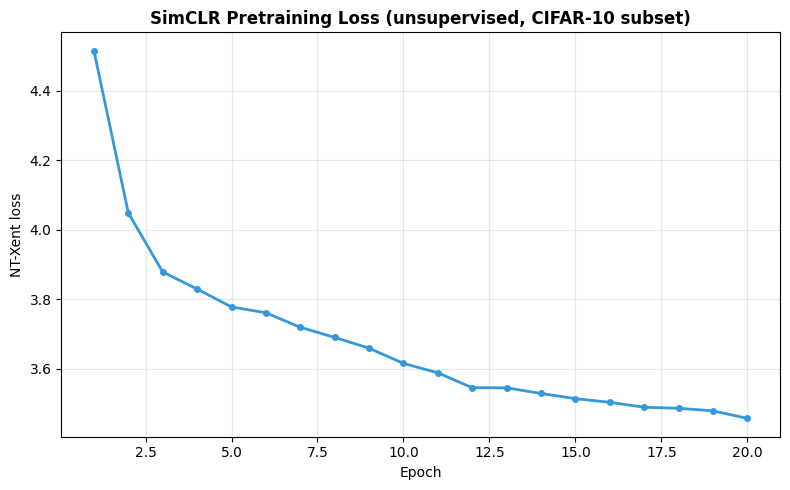

Saved simclr_loss_curve.png


In [7]:
# ── Loss curve ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(range(1, N_EPOCHS + 1), simclr_loss_history, color='#3498db', lw=2, marker='o', ms=4)
plt.xlabel('Epoch'); plt.ylabel('NT-Xent loss')
plt.title('SimCLR Pretraining Loss (unsupervised, CIFAR-10 subset)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('simclr_loss_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved simclr_loss_curve.png')

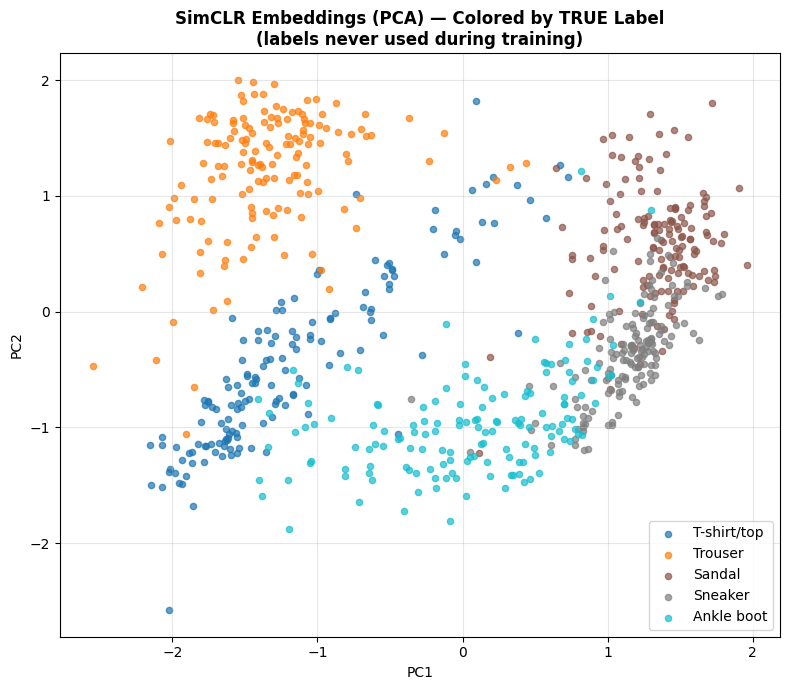

Saved simclr_embeddings.png
Even though no labels were used in training, same-class points visibly cluster together.


In [8]:
# ── Do the (label-free) embeddings actually separate classes? ─────────────────
eval_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
eval_ds = TwoViewDataset(raw_ds, idxs, eval_tf)   # deterministic transform, two identical "views"
eval_dl = DataLoader(eval_ds, batch_size=128, shuffle=False)

encoder.eval()
all_feats, all_labels = [], []
with torch.no_grad():
    for view_a, _, labels in eval_dl:
        feats = encoder(view_a.to(DEVICE))
        all_feats.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())
all_feats = np.concatenate(all_feats)
all_labels = np.concatenate(all_labels)

pca = PCA(n_components=2, random_state=42)
feats_2d = pca.fit_transform(all_feats)

class_names = {0: 'T-shirt/top', 1: 'Trouser', 5: 'Sandal', 7: 'Sneaker', 9: 'Ankle boot'}
colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax = plt.subplots(figsize=(8, 7))
for c in CLASSES:
    m = all_labels == c
    ax.scatter(feats_2d[m, 0], feats_2d[m, 1], s=20, alpha=0.7, color=colors[c], label=class_names[c])
ax.set_title('SimCLR Embeddings (PCA) — Colored by TRUE Label\n(labels never used during training)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('simclr_embeddings.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved simclr_embeddings.png')
print("Even though no labels were used in training, same-class points visibly cluster together.")

## Section 4: MoCo — Momentum Encoder & Dynamic Queue

SimCLR needs a **large batch** to get enough negatives (the paper uses batches of 4096+).
MoCo (He et al., 2020) decouples the negative count from the batch size with two ideas:

1. **Two encoders** — a *query* encoder $f_q$ (trained by backprop, as usual) and a *key*
   encoder $f_k$ (never receives gradients directly)
2. **Momentum update** — after every step, $f_k$ is nudged towards $f_q$:
   $$\theta_k \leftarrow m\,\theta_k + (1-m)\,\theta_q \qquad (m \approx 0.999)$$
   This makes $f_k$ change *slowly and smoothly*, so keys computed at different training
   steps stay roughly consistent with each other — which matters because...
3. **A queue (memory bank)** — keys from recent batches are kept in a FIFO queue (thousands
   of negatives) instead of being drawn only from the current batch. Because $f_k$ evolves
   slowly, old queue entries are still valid negatives even many steps later.

The loss is InfoNCE — identical in spirit to NT-Xent, but negatives come from the queue
instead of the rest of the batch.


In [9]:
# ── MoCo: query/key encoders + momentum update + queue ─────────────────────────
MOCO_DIM = 32
MOCO_QUEUE_SIZE = 512
MOCO_MOMENTUM = 0.99
MOCO_TEMPERATURE = 0.2

query_encoder = nn.Sequential(TinyEncoder(64), ProjectionHead(64, 64, MOCO_DIM)).to(DEVICE)
key_encoder = copy.deepcopy(query_encoder).to(DEVICE)
for p in key_encoder.parameters():
    p.requires_grad = False   # key encoder is NEVER updated by backprop

# FIFO queue of negative keys, L2-normalised
queue = F.normalize(torch.randn(MOCO_QUEUE_SIZE, MOCO_DIM), dim=1).to(DEVICE)
queue_ptr = 0

def moco_momentum_update(m=MOCO_MOMENTUM):
    with torch.no_grad():
        for p_q, p_k in zip(query_encoder.parameters(), key_encoder.parameters()):
            p_k.data.mul_(m).add_(p_q.data, alpha=1 - m)

@torch.no_grad()
def dequeue_and_enqueue(keys):
    global queue, queue_ptr
    bs = keys.size(0)
    end = queue_ptr + bs
    if end <= MOCO_QUEUE_SIZE:
        queue[queue_ptr:end] = keys
    else:  # wrap around
        first = MOCO_QUEUE_SIZE - queue_ptr
        queue[queue_ptr:] = keys[:first]
        queue[:end - MOCO_QUEUE_SIZE] = keys[first:]
    queue_ptr = end % MOCO_QUEUE_SIZE

n_params_moco = sum(p.numel() for p in query_encoder.parameters())
print(f'MoCo query/key encoder params (each): {n_params_moco:,}')
print(f'Queue: {MOCO_QUEUE_SIZE} negatives x {MOCO_DIM}-d | momentum m={MOCO_MOMENTUM}')

MoCo query/key encoder params (each): 29,760
Queue: 512 negatives x 32-d | momentum m=0.99


In [10]:
# ── MoCo training loop ───────────────────────────────────────────────────────
N_STEPS_MOCO = 120
moco_opt = torch.optim.Adam(query_encoder.parameters(), lr=3e-4)
moco_loss_history, param_dist_history = [], []

moco_dl_iter = iter(DataLoader(simclr_ds, batch_size=64, shuffle=True, drop_last=True))

for step in range(1, N_STEPS_MOCO + 1):
    try:
        view_a, view_b, _ = next(moco_dl_iter)
    except StopIteration:
        moco_dl_iter = iter(DataLoader(simclr_ds, batch_size=64, shuffle=True, drop_last=True))
        view_a, view_b, _ = next(moco_dl_iter)
    view_a, view_b = view_a.to(DEVICE), view_b.to(DEVICE)

    q = F.normalize(query_encoder(view_a), dim=1)                 # (B, D) queries, gradients flow
    with torch.no_grad():
        k = F.normalize(key_encoder(view_b), dim=1)                # (B, D) keys, NO gradients

    l_pos = (q * k).sum(dim=1, keepdim=True)                       # (B, 1) positive logits
    l_neg = q @ queue.t()                                          # (B, K) negative logits vs queue
    logits = torch.cat([l_pos, l_neg], dim=1) / MOCO_TEMPERATURE
    labels = torch.zeros(logits.size(0), dtype=torch.long, device=DEVICE)  # positive is always index 0

    loss = F.cross_entropy(logits, labels)
    moco_opt.zero_grad(); loss.backward(); moco_opt.step()

    moco_momentum_update()
    dequeue_and_enqueue(k)

    with torch.no_grad():
        dist = sum((pq - pk).pow(2).sum() for pq, pk in
                    zip(query_encoder.parameters(), key_encoder.parameters())).sqrt().item()
    moco_loss_history.append(loss.item())
    param_dist_history.append(dist)

    if step == 1 or step % 20 == 0 or step == N_STEPS_MOCO:
        print(f'Step {step:3d}/{N_STEPS_MOCO} | InfoNCE loss: {loss.item():.4f} | '
              f'||theta_q - theta_k||: {dist:.4f}')

Step   1/120 | InfoNCE loss: 2.2444 | ||theta_q - theta_k||: 0.0496


Step  20/120 | InfoNCE loss: 5.6670 | ||theta_q - theta_k||: 0.3801


Step  40/120 | InfoNCE loss: 5.4706 | ||theta_q - theta_k||: 0.5040


Step  60/120 | InfoNCE loss: 5.1980 | ||theta_q - theta_k||: 0.5303


Step  80/120 | InfoNCE loss: 4.8877 | ||theta_q - theta_k||: 0.5158


Step 100/120 | InfoNCE loss: 4.7909 | ||theta_q - theta_k||: 0.4927


Step 120/120 | InfoNCE loss: 4.7879 | ||theta_q - theta_k||: 0.4848


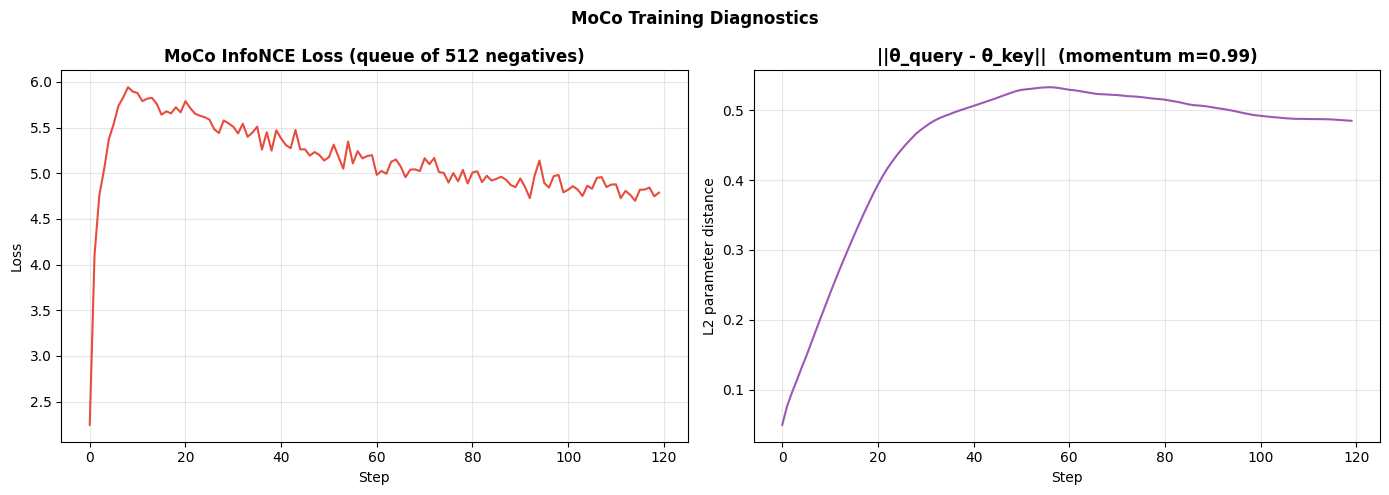

Saved moco_training.png
The key encoder trails the query encoder smoothly instead of jumping every step -
that smoothness is exactly what keeps the queue's old negatives still meaningful.


In [11]:
# ── MoCo diagnostics ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(moco_loss_history, color='#e74c3c', lw=1.5)
axes[0].set_title('MoCo InfoNCE Loss (queue of 512 negatives)', fontweight='bold')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(param_dist_history, color='#9b59b6', lw=1.5)
axes[1].set_title(f'||θ_query - θ_key||  (momentum m={MOCO_MOMENTUM})', fontweight='bold')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('L2 parameter distance'); axes[1].grid(True, alpha=0.3)

plt.suptitle('MoCo Training Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('moco_training.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved moco_training.png')
print("The key encoder trails the query encoder smoothly instead of jumping every step -")
print("that smoothness is exactly what keeps the queue's old negatives still meaningful.")

## Section 5: DINO — Self-Distillation with No Negatives

DINO (Caron et al., 2021) drops negatives entirely. A **student** and a **teacher** (same
architecture) each see a different augmented view; the student is trained to match the
teacher's output *distribution* with a cross-entropy loss — pure self-distillation:

$$\mathcal{L} = -\sum P_t(x_t) \log P_s(x_s), \qquad
P_t = \text{softmax}\!\left(\frac{g_t(x_t) - c}{\tau_t}\right),\quad
P_s = \text{softmax}\!\left(\frac{g_s(x_s)}{\tau_s}\right)$$

- The **teacher** is again an EMA of the student's weights (no gradients, momentum update —
  same idea as MoCo's key encoder), and gradients are **only** backpropagated through the
  student
- Because there are no negatives to push apart, this setup is prone to **collapse**: both
  networks can trivially minimise the loss by outputting the *same constant vector* for
  every image. DINO prevents this two ways:
  - **Centering** — subtract a running mean $c$ (EMA over teacher outputs) from the
    teacher's logits before the softmax, stopping any single dimension from dominating
  - **Sharpening** — use a **low temperature** $\tau_t$ for the teacher (sharper, more
    confident distribution) vs a higher $\tau_s$ for the student

Let's demonstrate the collapse failure mode directly: train the *same* student/teacher
setup with and without centering, and watch the diversity of the teacher's output collapse
when centering is removed.


In [12]:
# ── DINO: student/teacher setup ─────────────────────────────────────────────────
DINO_DIM = 16          # small "prototype" output dimension (like a tiny softmax codebook)
DINO_TEACHER_TEMP = 0.04
DINO_STUDENT_TEMP = 0.1
DINO_CENTER_MOMENTUM = 0.9
DINO_EMA_MOMENTUM = 0.99

def make_dino_networks():
    student = nn.Sequential(TinyEncoder(64), ProjectionHead(64, 64, DINO_DIM)).to(DEVICE)
    teacher = copy.deepcopy(student).to(DEVICE)
    for p in teacher.parameters():
        p.requires_grad = False
    return student, teacher

def dino_ema_update(student, teacher, m=DINO_EMA_MOMENTUM):
    with torch.no_grad():
        for p_s, p_t in zip(student.parameters(), teacher.parameters()):
            p_t.data.mul_(m).add_(p_s.data, alpha=1 - m)

def dino_loss(student_out, teacher_out, center, use_centering):
    """student_out, teacher_out: (B, DINO_DIM) raw logits (pre-softmax)."""
    t_logits = teacher_out - center if use_centering else teacher_out
    t_prob = F.softmax(t_logits / DINO_TEACHER_TEMP, dim=1).detach()
    s_log_prob = F.log_softmax(student_out / DINO_STUDENT_TEMP, dim=1)
    return -(t_prob * s_log_prob).sum(dim=1).mean()

print(f'DINO output dim: {DINO_DIM} | teacher temp: {DINO_TEACHER_TEMP} (sharp) | '
      f'student temp: {DINO_STUDENT_TEMP} | EMA momentum: {DINO_EMA_MOMENTUM}')

DINO output dim: 16 | teacher temp: 0.04 (sharp) | student temp: 0.1 | EMA momentum: 0.99


In [13]:
# ── Train DINO twice: WITH centering vs WITHOUT centering ──────────────────────
def train_dino(use_centering, n_steps=120, seed=0):
    torch.manual_seed(seed)
    student, teacher = make_dino_networks()
    opt = torch.optim.Adam(student.parameters(), lr=3e-4)
    center = torch.zeros(1, DINO_DIM).to(DEVICE)

    loss_hist, teacher_sim_hist = [], []
    dl_iter = iter(DataLoader(simclr_ds, batch_size=64, shuffle=True, drop_last=True))

    for step in range(1, n_steps + 1):
        try:
            view_a, view_b, _ = next(dl_iter)
        except StopIteration:
            dl_iter = iter(DataLoader(simclr_ds, batch_size=64, shuffle=True, drop_last=True))
            view_a, view_b, _ = next(dl_iter)
        view_a, view_b = view_a.to(DEVICE), view_b.to(DEVICE)

        student_out = student(view_a)
        with torch.no_grad():
            teacher_out = teacher(view_b)

        loss = dino_loss(student_out, teacher_out, center, use_centering)
        opt.zero_grad(); loss.backward(); opt.step()

        dino_ema_update(student, teacher)
        if use_centering:
            with torch.no_grad():
                center = DINO_CENTER_MOMENTUM * center + (1 - DINO_CENTER_MOMENTUM) * teacher_out.mean(dim=0, keepdim=True)

        with torch.no_grad():
            # Collapse = every image gets (almost) the same teacher output. Measure the
            # mean pairwise cosine similarity of teacher outputs WITHIN the batch: a
            # healthy, diverse representation keeps this low; total collapse pushes it to 1.
            t_norm = F.normalize(teacher_out, dim=1)
            pairwise_sim = t_norm @ t_norm.t()
            off_diag = pairwise_sim[~torch.eye(pairwise_sim.size(0), dtype=torch.bool, device=DEVICE)]
            teacher_sim_hist.append(off_diag.mean().item())

        loss_hist.append(loss.item())

    return loss_hist, teacher_sim_hist

print('Training DINO WITH centering...')
loss_with, simcollapse_with = train_dino(use_centering=True)
print(f'  final loss: {loss_with[-1]:.4f} | final avg pairwise cosine sim of teacher outputs: {simcollapse_with[-1]:.4f}')

print('Training DINO WITHOUT centering (collapse ablation)...')
loss_without, simcollapse_without = train_dino(use_centering=False)
print(f'  final loss: {loss_without[-1]:.4f} | final avg pairwise cosine sim of teacher outputs: {simcollapse_without[-1]:.4f}')
print('\nA pairwise similarity close to 1.0 means every image gets (almost) the same teacher')
print('output -- that IS collapse. Centering should keep this substantially lower.')
print('\nNote the trap: the WITHOUT-centering run typically ends with a LOWER loss than the')
print('WITH-centering run. That is not an improvement -- collapsing to one constant output')
print('is a trivial, easy way to minimise cross-entropy (student and teacher trivially agree).')
print('The pairwise-similarity plot below is the metric that actually reveals which run is healthy.')

Training DINO WITH centering...


  final loss: 2.0512 | final avg pairwise cosine sim of teacher outputs: 0.5313
Training DINO WITHOUT centering (collapse ablation)...


  final loss: 0.2823 | final avg pairwise cosine sim of teacher outputs: 0.9734

A pairwise similarity close to 1.0 means every image gets (almost) the same teacher
output -- that IS collapse. Centering should keep this substantially lower.

Note the trap: the WITHOUT-centering run typically ends with a LOWER loss than the
WITH-centering run. That is not an improvement -- collapsing to one constant output
is a trivial, easy way to minimise cross-entropy (student and teacher trivially agree).
The pairwise-similarity plot below is the metric that actually reveals which run is healthy.


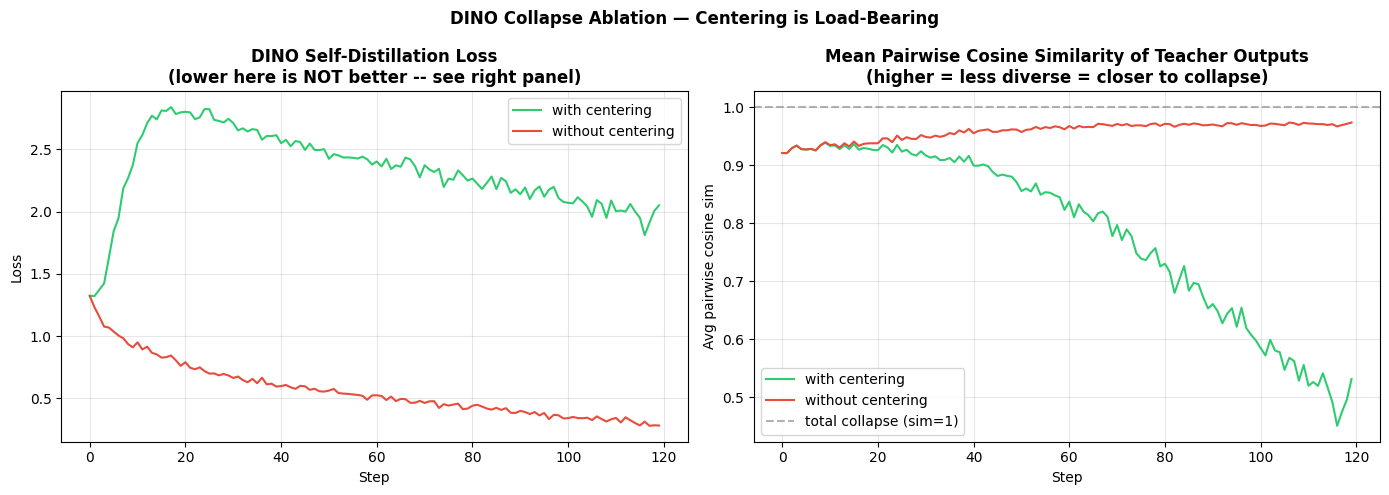

Saved dino_collapse_ablation.png


In [14]:
# ── Plot: loss + collapse ablation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_with, color='#2ecc71', lw=1.5, label='with centering')
axes[0].plot(loss_without, color='#e74c3c', lw=1.5, label='without centering')
axes[0].set_title('DINO Self-Distillation Loss\n(lower here is NOT better -- see right panel)', fontweight='bold')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(simcollapse_with, color='#2ecc71', lw=1.5, label='with centering')
axes[1].plot(simcollapse_without, color='#e74c3c', lw=1.5, label='without centering')
axes[1].axhline(1.0, color='grey', ls='--', alpha=0.6, label='total collapse (sim=1)')
axes[1].set_title('Mean Pairwise Cosine Similarity of Teacher Outputs\n(higher = less diverse = closer to collapse)', fontweight='bold')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Avg pairwise cosine sim'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('DINO Collapse Ablation — Centering is Load-Bearing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dino_collapse_ablation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved dino_collapse_ablation.png')

## Section 6: SimCLR vs MoCo vs DINO

| | SimCLR | MoCo | DINO |
|---|---|---|---|
| **Negatives** | rest of the batch | large FIFO queue | **none** |
| **Second network** | none (shared encoder for both views) | momentum key encoder | momentum teacher |
| **Loss** | NT-Xent (InfoNCE over batch) | InfoNCE over batch+queue | cross-entropy, student vs teacher distribution |
| **Needs large batch?** | yes (more negatives = better) | no (queue supplies negatives) | no |
| **Collapse risk** | low (negatives push apart) | low (negatives push apart) | high — needs centering + sharpening |
| **What's kept after pretraining** | encoder `f(·)` only | query encoder `f_q(·)` only | teacher (or student) encoder only |

All three converge on the same downstream recipe: **discard the projection/prototype head,
keep the backbone, freeze it, and reuse its features** — precisely the setup Friday's
5-shot classifier project builds on.


## Summary

- **Contrastive self-supervision** turns "make two augmentations of the same image agree,
  different images disagree" into a training signal that needs zero labels
- **NT-Xent / InfoNCE** implements this as a softmax classification: "which of the other
  views in this batch (or queue) is my true positive?"
- **MoCo's momentum encoder + queue** let negatives scale into the thousands without
  needing a huge batch, at the cost of a second (slowly-updated) network
- **DINO removes negatives entirely** via self-distillation, but that requires **centering**
  and **sharpening** to avoid the trivial constant-output collapse — demonstrated directly
  above by the pairwise-similarity ablation
- All three methods produce a **frozen, general-purpose encoder** as the actual deliverable
  — the contrastive/distillation machinery is scaffolding that gets thrown away after
  pretraining

**Next (Jul 16-17): MAE & Foundation Models** — a different self-supervised recipe (masked
patch reconstruction) and how these ideas scale up into DINOv2 and vision-language
foundation models.
